In [25]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere
from qiskit.visualization import plot_bloch_multivector
from qiskit.visualization import plot_histogram
from qiskit_aer import Aer
from qiskit import transpile

## 1. Bernstein-Varzirani Algorithm

The Bernstein-Vazirani algorithm identifies a hidden $n$-bit string $s$ in a single query by using a quantum register of $n$ qubits in superposition to evaluate all possible bit-string combinations simultaneously, followed by interference that collapses the state directly onto the value of $s$.

- **Parallelism**: The $n$ qubits are initialized into a state of $2^n$ possible strings using Hadamard $H$ gates.

- **The Oracle**: The hidden string $s$ is encoded into the phase of these qubits via a function $f(x) = s \cdot x \pmod 2$.

- **The Result**: A final set of Hadamard gates causes all "incorrect" paths to destructively interfere, leaving only the correct $n$-bit string $s$ to be measured with $100\%$ probability.

Just take the Oracle as the black‑box unitary ($U_f$) that encodes the hidden string ($s$). It’s implemented as CNOTs from each input qubit ($x_i$) to the ancilla when ($s_i=1$). That realizes ($f_s(x)=s\cdot x \bmod 2$) via phase kickback. _Note that $x \bmod 2$ is a result of boolean logic XOR using modulus of 2._

##### Why is it Faster than Classical Computer

For an 8-bit Classical computer, it has to go through $O(2^8)$ times of iterations as it has to do a for-loop to find the actual answer. For an 8-bit Quantum computer, it only needs to go through $O(1)$ times of iterations.

##### Steps

1. **T0**: Set the parallel qubits.
2. **T1**: Let the Oracle via $U_f = f(x) = s \cdot x \pmod 2$ function configures the bits that are $1$.
3. **T2**: End the superposition to start measurement.

### 1.1 Initialize the Secret Number

In [26]:
secret_number = '1000101' # remember left to right

### 1.2 Create the Quantum Circuit

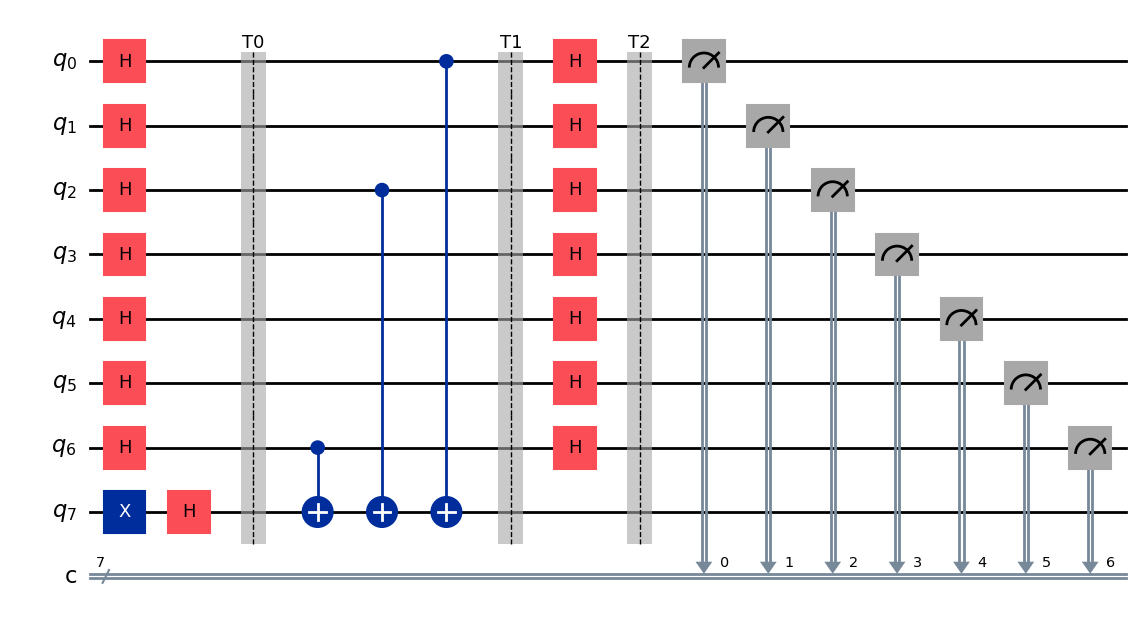

In [27]:
class BernsteinVaziraniAlgorithm:

    def __init__(self, bits):
        n = len(bits)
        self.qc = QuantumCircuit(n + 1, n)
        self._setup_parallel(n)
        self._oracle(n, bits)
        self._end_superposition(n)
        self._computational_result(n)
    
    def _setup_parallel(self, n):
        # Set all into uniform superposition basis
        self.qc.h([i for i in range(n)])
        # Prepares |-> CNOT kickback a phase instead of flipping the target.
        self.qc.x(n)
        self.qc.h(n)

    def _oracle(self, n, bits):
        self.qc.barrier(label="T0")
        # Configure based on the secret number using CNOT
        for i in range(n):
            if bits[i] == '1': self.qc.cx(n - i - 1,n)

    def _end_superposition(self, n):
        self.qc.barrier(label="T1")
        # Convert all into computational basis
        self.qc.h([i for i in range(n)])

    def _computational_result(self, n):
        self.qc.barrier(label="T2")
        # Measure for results in one short
        self.qc.measure([i for i in range(n)], [i for i in range(n)])

    def compute(self):
        qasm_simulator = Aer.get_backend('qasm_simulator')
        statevector_simulator = Aer.get_backend('statevector_simulator')
        compiled_circuit = transpile(self.qc, backend=qasm_simulator)
        job = statevector_simulator.run(compiled_circuit, shots=1024)
        return job.result().get_counts()

bva = BernsteinVaziraniAlgorithm(secret_number)
bva.qc.draw(output='mpl')

In [28]:
bva.compute()

{'1000101': 1024}

### 1.3 Initialize another Secret Number

This time longer,

In [29]:
secret_number = '100010101101' # remember left to right

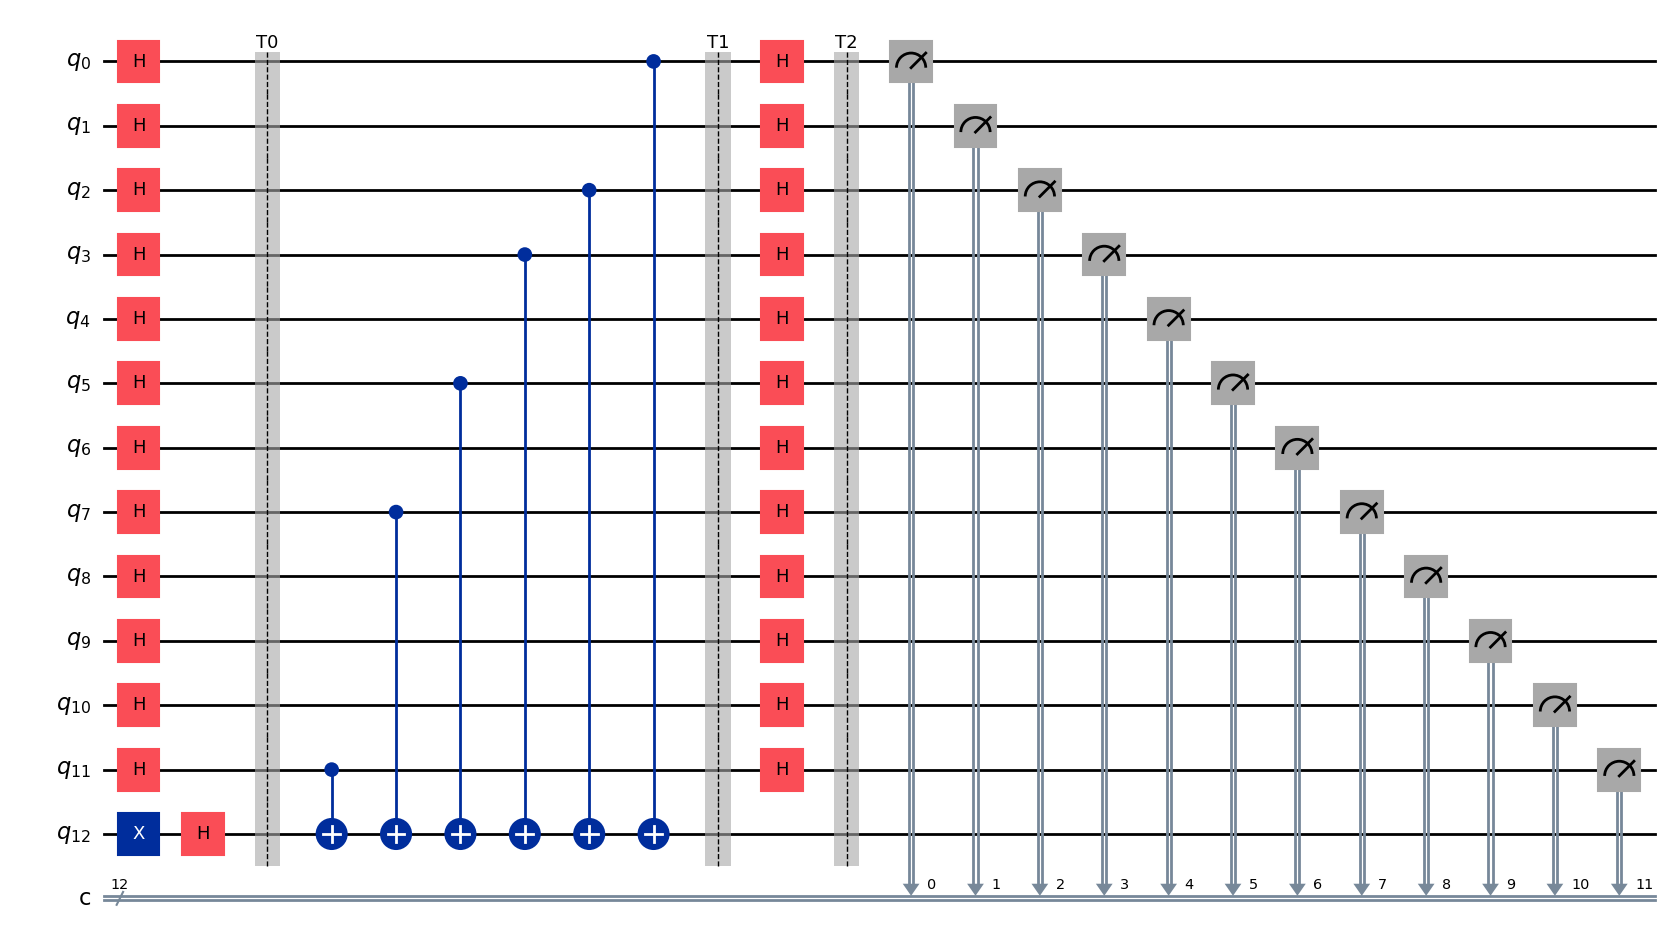

In [30]:
bva = BernsteinVaziraniAlgorithm(secret_number)
bva.qc.draw(output='mpl')

In [31]:
bva.compute()

{'100010101101': 1024}